# Agricultural Market Price Forecasting

This project aims to predict agricultural crop prices using historical market data.

Farmers often face uncertainty about when to sell their crops. By using machine learning, we can analyze historical price trends and forecast future prices to assist farmers in making better selling decisions.

The model used in this project is **Linear Regression**.

# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

The dataset contains agricultural market prices including:

- Commodity
- Market Name
- State
- Minimum Price
- Maximum Price
- Modal Price
- Date

Modal price represents the most common selling price in the market and will be used as the target variable.

In [2]:
df = pd.read_csv('agmarknet_india_historical_prices_2024_2025.csv')

In [3]:
df.head(5)

,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh


In [27]:
df['Commodity'].unique().sum()

'WheatMaizeBananaGreen Gram (Moong)(Whole)GroundnutMustardSoyabeanCottonAppleMangoGarlicCauliflowerBrinjalCarrotCabbageBhindi(Ladies Finger)Green ChilliGinger(Green)Gur(Jaggery)Jowar(Sorghum)Bajra(Pearl Millet/Cumbu)Arhar (Tur/Red Gram)(Whole)Lentil (Masur)(Whole)'

# Understanding the Dataset

In [4]:
df.shape

(1118899, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118899 entries, 0 to 1118898
Data columns (total 11 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Sl no.                     1118899 non-null  int64  
 1   District Name              1118899 non-null  str    
 2   Market Name                1118899 non-null  str    
 3   Commodity                  1118899 non-null  str    
 4   Variety                    1118899 non-null  str    
 5   Grade                      1118899 non-null  str    
 6   Min Price (Rs./Quintal)    1118899 non-null  float64
 7   Max Price (Rs./Quintal)    1118899 non-null  float64
 8   Modal Price (Rs./Quintal)  1118899 non-null  float64
 9   Price Date                 1118899 non-null  str    
 10  State                      1118899 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 93.9 MB


In [6]:
df.describe()

,Sl no.,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal)
count,1.118899e+06,1.118899e+06,1.118899e+06,1.118899e+06
mean,9.949148e+03,3.978400e+03,4.643819e+03,4.364553e+03
std,9.637049e+03,4.341166e+03,4.854203e+03,4.534411e+03
min,1.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01
25%,2.597000e+03,2.000000e+03,2.355000e+03,2.225000e+03
50%,6.849000e+03,3.000000e+03,3.800000e+03,3.500000e+03
75%,1.445300e+04,5.125000e+03,6.000000e+03,5.675000e+03
max,4.585900e+04,2.470000e+05,6.615110e+05,2.500000e+05


# Data Cleaning

Before training the model, we clean the dataset by:

- Removing duplicate rows
- Handling missing values
- Converting the date column into datetime format

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum()

Sl no.                       0
District Name                0
Market Name                  0
Commodity                    0
Variety                      0
Grade                        0
Min Price (Rs./Quintal)      0
Max Price (Rs./Quintal)      0
Modal Price (Rs./Quintal)    0
Price Date                   0
State                        0
dtype: int64

In [9]:
df['Price Date'] = pd.to_datetime(df['Price Date'], errors="coerce")

# Feature Engineering

We extract useful information from the date column such as:

- Year
- Month
- Day

These features help the model understand seasonal patterns in crop prices.

In [10]:
df['year'] = df['Price Date'].dt.year
df['month'] = df['Price Date'].dt.month
df['day'] = df['Price Date'].dt.day

# Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of crop prices and identify patterns in the dataset.

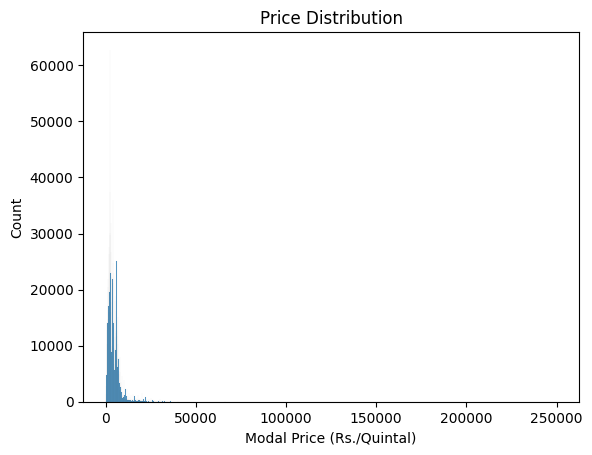

In [11]:
# Price Distribution 

sns.histplot(df['Modal Price (Rs./Quintal)'])
plt.title('Price Distribution')
plt.show()

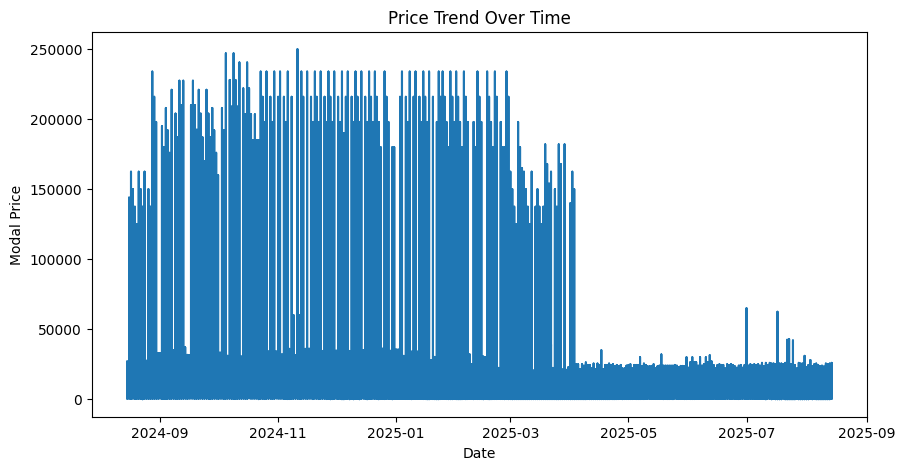

In [12]:
# Price Trend

df_sorted = df.sort_values('Price Date')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['Price Date'], df_sorted['Modal Price (Rs./Quintal)'])
plt.title("Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()

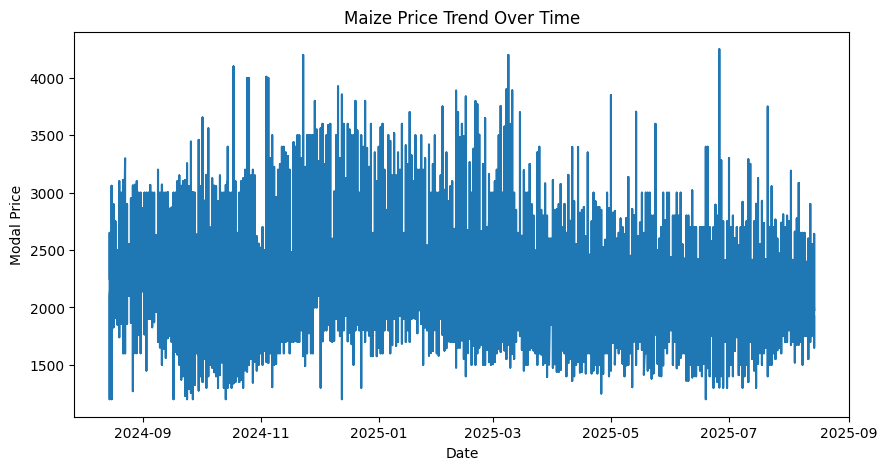

In [13]:
# Maize Trend

maize_df = df[df['Commodity'] == 'Maize']

maize_df = maize_df.sort_values('Price Date')

plt.figure(figsize=(10,5))
plt.plot(maize_df['Price Date'], maize_df['Modal Price (Rs./Quintal)'])

plt.title("Maize Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()

# Preparing Features for Machine Learning

The dataset contains both numerical and categorical variables.

To process them properly we use:

- StandardScaler for numerical features
- OneHotEncoder for categorical features

ColumnTransformer allows us to apply different transformations to different columns.  
This transformation pipeline is combined with the machine learning model using a Pipeline.

In [14]:
# Target Variable

y = df['Modal Price (Rs./Quintal)']

In [15]:
# Feature Columns 

x = df.drop(['Modal Price (Rs./Quintal)','Price Date','Sl no.'],axis=1)

# Identifying Numerical and Categorical Columns

In [16]:
numerical_cols = [
    'Min Price (Rs./Quintal)',
    'Max Price (Rs./Quintal)'
]

catagorical_cols = [
    'Commodity',
    'Market Name',
    'Variety',
    'Grade',
    'State',
    'District Name'
]

# Creating the Preprocessing Pipeline

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), catagorical_cols)
    ]
)

# Creating the Machine Learning Pipeline

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Splitting the Dataset

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Training the Model

In [21]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Making Predictions

In [22]:
y_pred = pipeline.predict(x_test)

# Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))

MAE:  161.22055129523608
MSE:  295028.91064273816
R2 Score:  0.9843552244211959


# Model Performance Interpretation

The Linear Regression model achieved an R² score of 0.984, indicating that the model explains approximately 98.4% of the variance in crop prices.

The Mean Absolute Error (MAE) is around 161 Rs per quintal, which means the model's predictions are on average off by about ₹161.

Overall, the model demonstrates strong predictive performance on the test dataset.

# Advantages of Using Pipeline

Using a pipeline ensures that:

- Data preprocessing and model training are combined into a single workflow.
- The same preprocessing steps are applied to both training and test data.
- The workflow becomes easier to deploy in production environments.

# Saving the Trained Model

After training the machine learning pipeline, we save the model using Pickle.

Saving the model allows us to reuse it later in a web application without retraining.

In [24]:
import pickle

with open("crop_price_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [28]:
x.columns

Index(['District Name', 'Market Name', 'Commodity', 'Variety', 'Grade',
       'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'State', 'year',
       'month', 'day'],
      dtype='str')